# Analysis of L2-regularization on the mouse brain dataset

In [1]:
import pandas as pd
import numpy as np
import scanpy as sc
import anndata as ad
import os

import warnings
warnings.filterwarnings("ignore")

os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import sys
sys.path.append(r'/import/home2/share/yqzeng/MacSGP/codes')
import MacSGP

In [2]:
DATA_PATH = "/import/home2/share/yqzeng/MacSGP/data/Mouth_brain_visium" # Raw data
SAVE_PATH = "/import/home2/share/yqzeng/MacSGP/Results/Mouth_brain_visium" # Deconvolution results
os.makedirs(os.path.join(SAVE_PATH), exist_ok = True)

In [7]:
adata_st = ad.read_h5ad(os.path.join(DATA_PATH, "visium_1.h5ad"))
adata_basis = ad.read_h5ad(os.path.join(DATA_PATH, "visium_1_basis.h5ad"))

In [16]:
model = MacSGP.model.Model(adata_st, adata_basis, n_layers=4, training_steps=6000, coef_reg=0.05)

model.train(step_interval=300, reg_mode="L1")
adata_result = model.eval()

  0%|          | 2/6000 [00:00<16:53,  5.92it/s]

Step: 0, Loss: -5790.5874, d_loss: -5795.3467, f_loss: 47.3751, reg_loss: 0.0471


  5%|▌         | 302/6000 [00:50<16:02,  5.92it/s]

Step: 300, Loss: -6015.6699, d_loss: -6019.5962, f_loss: 23.1051, reg_loss: 3.4936


 10%|█         | 602/6000 [01:41<15:10,  5.93it/s]

...

 90%|█████████ | 5402/6000 [15:12<01:41,  5.91it/s]

Step: 5400, Loss: -6133.5044, d_loss: -6139.3950, f_loss: 20.6207, reg_loss: 8.2782


 95%|█████████▌| 5702/6000 [16:03<00:50,  5.91it/s]

Step: 5700, Loss: -6134.7549, d_loss: -6140.8169, f_loss: 20.5936, reg_loss: 8.6543


100%|██████████| 6000/6000 [16:53<00:00,  5.92it/s]


In [20]:
adata_result.write_h5ad(os.path.join(SAVE_PATH, "visium_1_result_l1_0.05.h5ad"))

In [3]:
adata_result = sc.read_h5ad(os.path.join(SAVE_PATH, "visium_1_result_l1_0.05.h5ad"))

Dropping cell types: []


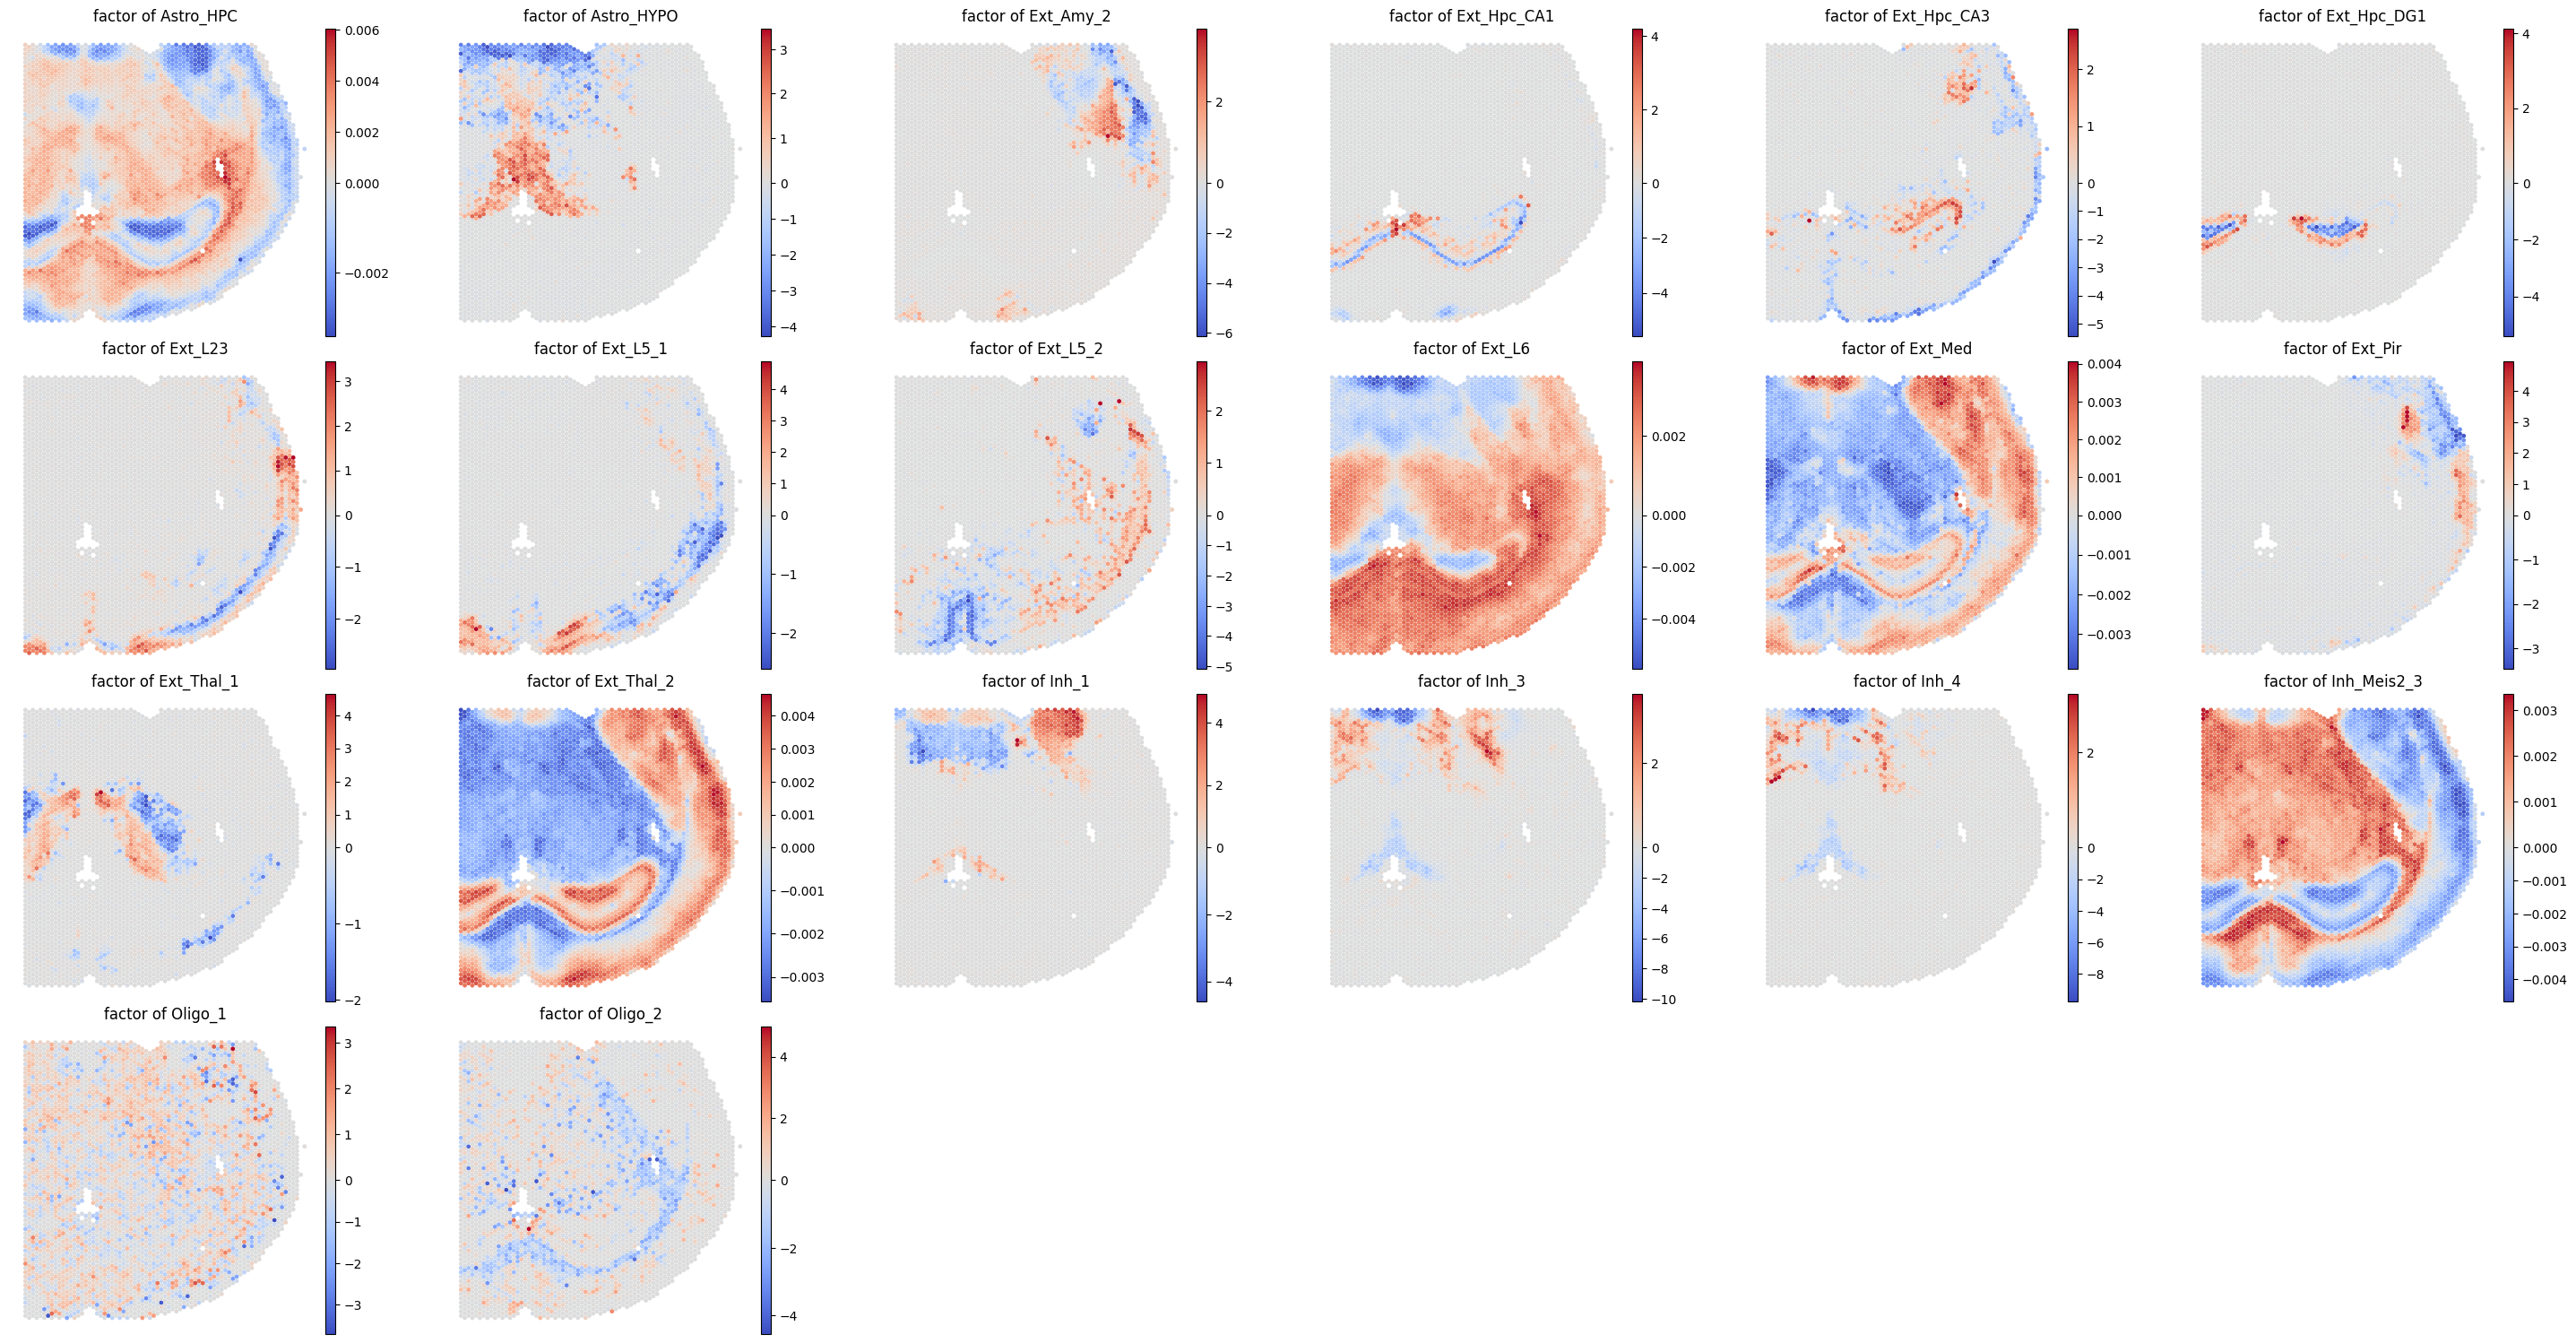

In [17]:

ct_plot = ['Astro_HPC','Astro_HYPO','Ext_Amy_2','Ext_Hpc_CA1','Ext_Hpc_CA3','Ext_Hpc_DG1',
 'Ext_L23','Ext_L5_1','Ext_L5_2','Ext_L6','Ext_Med','Ext_Pir','Ext_Thal_1','Ext_Thal_2','Inh_1','Inh_3','Inh_4','Inh_Meis2_3','Oligo_1','Oligo_2']
from MacSGP.vis import plot_spatial_ct

plot_spatial_ct(adata_result, index='factor', celltype_plot=ct_plot,
                proportion_threshold=0.0, num_threshold=100, 
                cmap='coolwarm', 
                spot_size=100, 
                ncols=6)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from scipy.stats import pearsonr
from libpysal.weights import KNN
import matplotlib as mpl

mpl.rcParams.update({
    'font.family': 'Helvetica', 
    'font.size': 7,
    'axes.titlesize': 8,
    'axes.labelsize': 7,
    'xtick.labelsize': 6.5,
    'ytick.labelsize': 6.5,
    'axes.linewidth': 0.5,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'xtick.major.size': 2.5,
    'ytick.major.size': 2.5,
    'pdf.fonttype': 42,      
    'ps.fonttype': 42,
    'savefig.dpi': 300,
    'figure.dpi': 150,
})

In [5]:
ct_plot = ['Ext_Med', 'Ext_Pir', 'Ext_Thal_1', 'Ext_Thal_2']

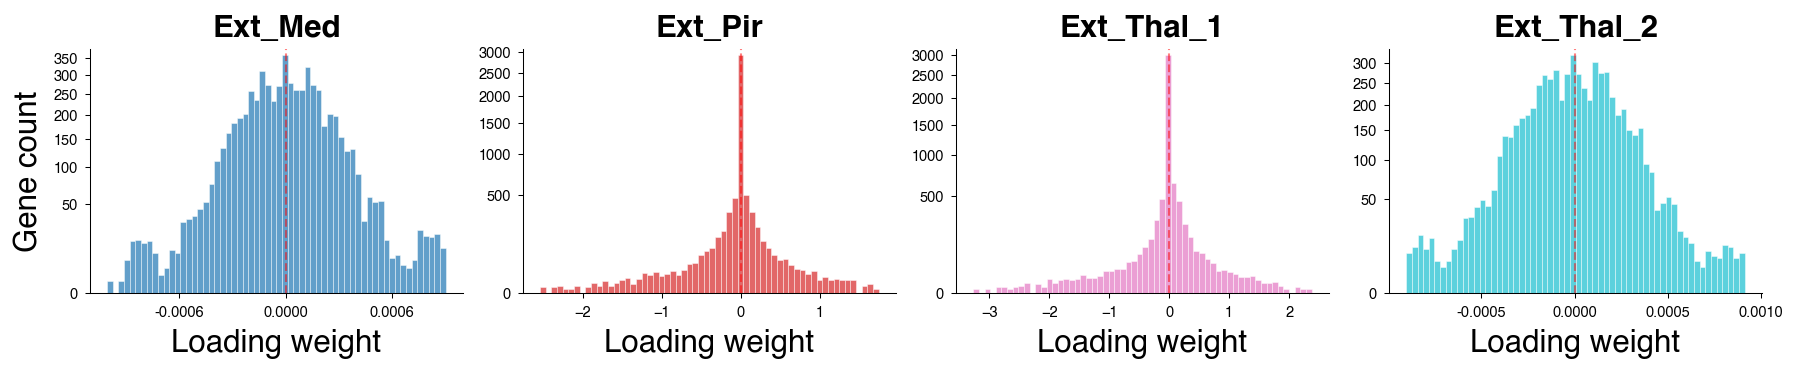

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, FormatStrFormatter
loadings = adata_result.varm['loading'][ct_plot]
if hasattr(loadings, 'columns'):
    ct_names = list(loadings.columns)
    loadings = loadings.values
else:
    ct_names = [f'CT_{i}' for i in range(loadings.shape[1])]

n_ct = loadings.shape[1]
ncols = 4
nrows = int(np.ceil(n_ct / ncols))

#clip = np.percentile(np.abs(loadings), 99.5)

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 2.5))
axes = axes.flatten()
cmap = plt.cm.get_cmap('tab10', n_ct)

for i in range(n_ct):
    ax = axes[i]
    vec = loadings[:, i]
    #vec_clip = vec[(vec > -clip) & (vec < clip)]
    
    ax.hist(vec, bins=60, color=cmap(i), alpha=0.7, edgecolor='white', linewidth=0.3)
    ax.axvline(x=0, color='red', linestyle='--', alpha=0.5, linewidth=1)
    ax.set_yscale('function', functions=(np.sqrt, np.square))
    ax.set_title(ct_names[i], fontsize=15, fontweight='bold')
    #ax.set_xlim(-clip, clip)
    #if i >= ncols:
    ax.set_xlabel('Loading weight', fontsize=15)
    if i % ncols == 0:
        ax.set_ylabel('Gene count', fontsize=15)
    ax.tick_params(labelsize=7, )
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if ct_names[i] in ['Ext_Med', 'Ext_Thal_2']:
        ax.xaxis.set_major_locator(MaxNLocator(nbins=4))      
        ax.xaxis.set_major_formatter(FormatStrFormatter('%.4f')) 

for j in range(n_ct, len(axes)):
    axes[j].set_visible(False)

#fig.suptitle('Gene Loading Distribution per Cell Type', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

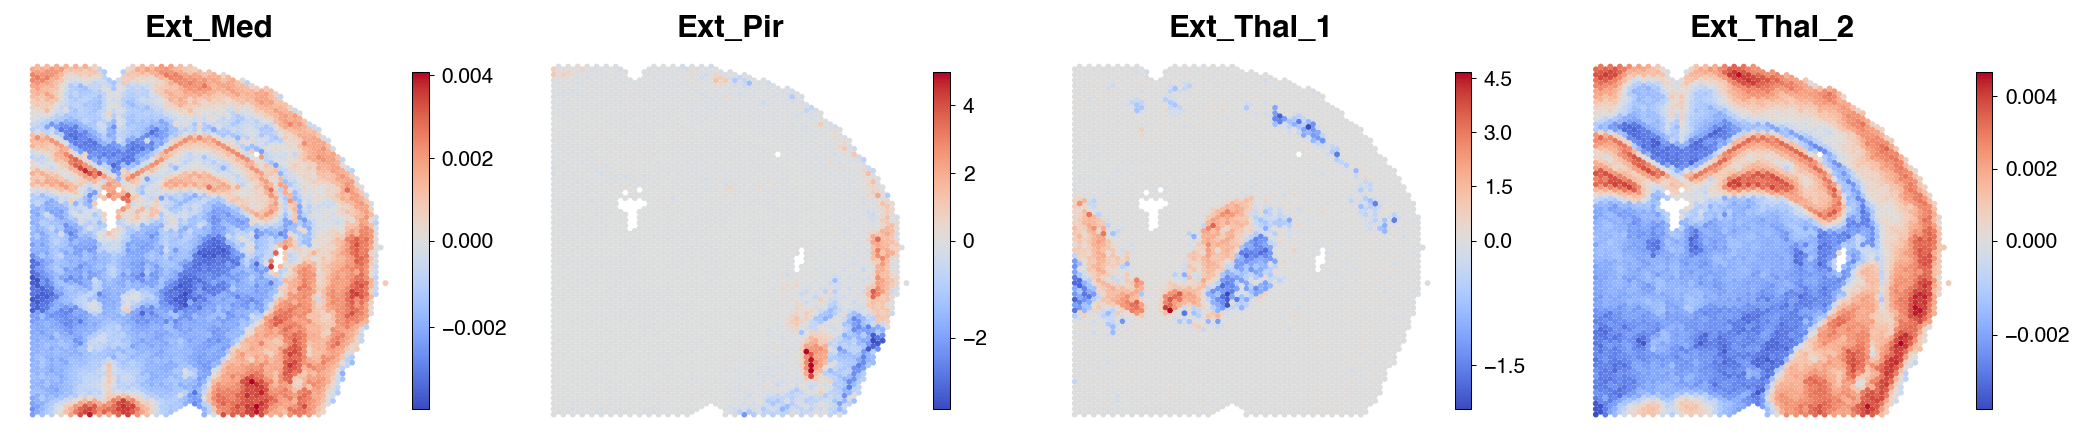

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib.ticker import MaxNLocator

factors = adata_result.obsm['factor']
ct_names = ct_plot
factor_mat = factors
spatial = adata_result.obsm['spatial']
x, y = spatial[:, 0], spatial[:, 1]

n_ct = len(ct_names)
ncols = 4
nrows = int(np.ceil(n_ct / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 3.2))
axes = axes.flatten()

for i, ct in enumerate(ct_names):
    ax = axes[i]
    vec = factors[ct]
    vmax = np.percentile(np.abs(vec), 99)
    #norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    norm = TwoSlopeNorm(vcenter=0)
    sc = ax.scatter(x, y, c=vec, cmap='coolwarm', norm=norm,
                    s=8, linewidths=0)#, rasterized=True)
    cb = fig.colorbar(sc, ax=ax, shrink=0.75, pad=0.02)
    cb.locator = MaxNLocator(nbins=5)
    cb.update_ticks()
    cb.ax.tick_params(labelsize=10)
    ax.set_title(ct, fontsize=15, fontweight='bold')
    ax.set_aspect('equal')
    ax.axis('off')

for j in range(n_ct, len(axes)):
    axes[j].set_visible(False)

#plt.suptitle('Spatial factor distribution per cell type', fontsize=13, fontweight='bold')
plt.tight_layout()
#plt.savefig('factor_spatial.pdf', dpi=300, bbox_inches='tight')
plt.show()

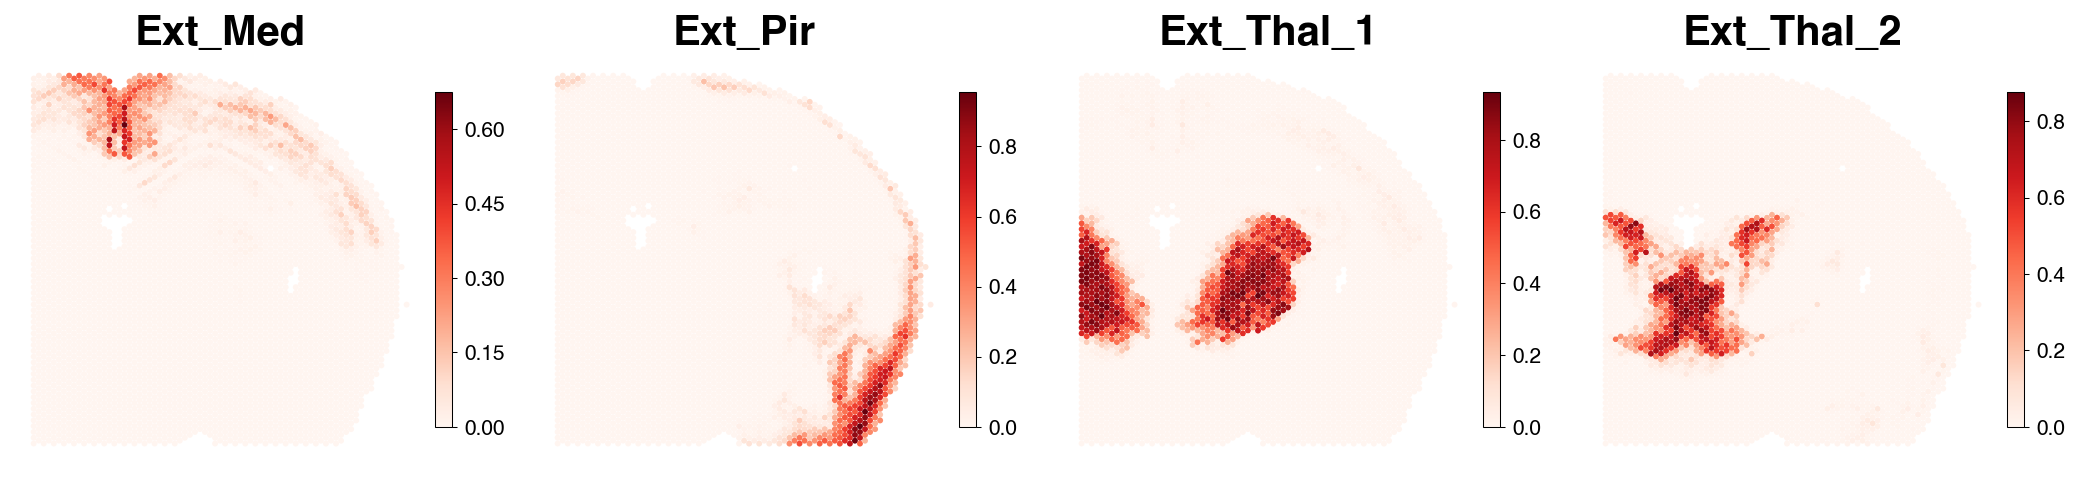

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib.ticker import MaxNLocator

factors = adata_result.obsm['proportion']
ct_names = ct_plot
factor_mat = factors
spatial = adata_result.obsm['spatial']
x, y = spatial[:, 0], spatial[:, 1]

n_ct = len(ct_names)
ncols = 4
nrows = int(np.ceil(n_ct / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 3.2))
axes = axes.flatten()

for i, ct in enumerate(ct_names):
    ax = axes[i]
    vec = factors[ct]
    vmax = np.percentile(np.abs(vec), 99)
    #norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    norm = TwoSlopeNorm(vcenter=0)
    sc = ax.scatter(x, y, c=vec, cmap='Reds', #norm=norm,
                    s=8, linewidths=0)#, rasterized=True)
    cb = fig.colorbar(sc, ax=ax, shrink=0.75, pad=0.02)
    cb.locator = MaxNLocator(nbins=5)
    cb.update_ticks()
    cb.ax.tick_params(labelsize=10)
    ax.set_title(ct, fontsize=20, fontweight='bold')
    ax.set_aspect('equal')
    ax.axis('off')

for j in range(n_ct, len(axes)):
    axes[j].set_visible(False)

#plt.suptitle('Spatial factor distribution per cell type', fontsize=13, fontweight='bold')
plt.tight_layout()
#plt.savefig('factor_spatial.pdf', dpi=300, bbox_inches='tight')
plt.show()

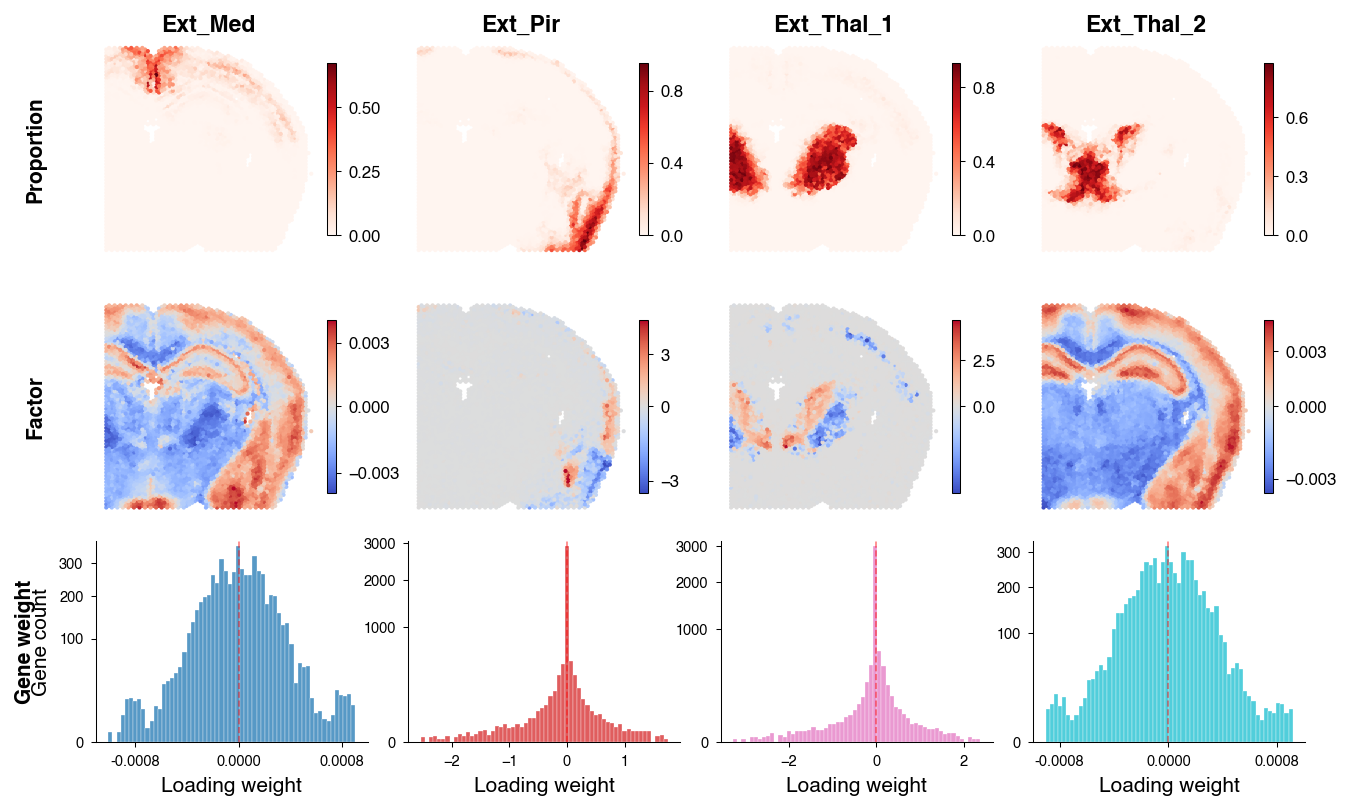

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib.ticker import MaxNLocator, FormatStrFormatter

ct_names = ct_plot   # ['Ext_Med', 'Ext_Pir', 'Ext_Thal_1', 'Ext_Thal_2']
n_ct = len(ct_names)
ncols = n_ct
nrows = 3

spatial = adata_result.obsm['spatial']
x, y = spatial[:, 0], spatial[:, 1]

proportions = adata_result.obsm['proportion']
factors     = adata_result.obsm['factor']
loadings    = adata_result.varm['loading'][ct_names].values

row_h = [2.2, 2.2, 1.8]
fig = plt.figure(figsize=(ncols * 2.6, sum(row_h)))
gs = fig.add_gridspec(nrows, ncols,
                      height_ratios=row_h,
                      hspace=0.05, wspace=0.15)

row_labels = ['Proportion', 'Factor', 'Gene weight']
cmap_tab = plt.cm.get_cmap('tab10', n_ct)

for row in range(nrows):
    for col, ct in enumerate(ct_names):
        ax = fig.add_subplot(gs[row, col])

        if row == 0:
            vec = proportions[ct]
            sc = ax.scatter(x, y, c=vec, cmap='Reds', s=4, linewidths=0)
            cb = fig.colorbar(sc, ax=ax, shrink=0.7, pad=0.02)
            cb.locator = MaxNLocator(nbins=3)
            cb.update_ticks()
            cb.ax.tick_params(labelsize=8)
            ax.set_aspect('equal')
            ax.axis('off')

        elif row == 1:
            vec = factors[ct]
            norm = TwoSlopeNorm(vcenter=0)
            sc = ax.scatter(x, y, c=vec, cmap='coolwarm', norm=norm,
                            s=4, linewidths=0)
            cb = fig.colorbar(sc, ax=ax, shrink=0.7, pad=0.02)
            cb.locator = MaxNLocator(nbins=3)
            cb.update_ticks()
            cb.ax.tick_params(labelsize=8)
            ax.set_aspect('equal')
            ax.axis('off')

        else:
            vec = loadings[:, col]
            ax.hist(vec, bins=60, color=cmap_tab(col),
                    alpha=0.75, edgecolor='white', linewidth=0.2)
            ax.axvline(x=0, color='red', linestyle='--', alpha=0.5, linewidth=0.8)
            ax.set_yscale('function', functions=(np.sqrt, np.square))
            ax.set_xlabel('Loading weight', fontsize=10)
            if col == 0:
                ax.set_ylabel('Gene count', fontsize=10)
            ax.tick_params(labelsize=7)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)

            if ct in ['Ext_Med', 'Ext_Thal_2']:
                ax.xaxis.set_major_locator(MaxNLocator(nbins=3))
                ax.xaxis.set_major_formatter(FormatStrFormatter('%.4f'))

        if row == 0:
            ax.set_title(ct, fontsize=11, fontweight='bold', pad=3)

        if col == 0:
            ax.annotate(row_labels[row],
                        xy=(-0.22, 0.5), xycoords='axes fraction',
                        fontsize=10, fontweight='bold',
                        ha='right', va='center', rotation=90)

plt.show()
